

# Getting the DS


In [ ]:
!pip -q install datasets pyarrow

from datasets import load_dataset

ds = load_dataset("bogdancazan/wikilarge-text-simplification")
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


wiki.full.aner.ori.train.95.tsv:   0%|          | 0.00/36.3M [00:00<?, ?B/s]

wiki.full.aner.ori.valid.95.tsv:   0%|          | 0.00/121k [00:00<?, ?B/s]

wiki.full.aner.ori.test.95.tsv:   0%|          | 0.00/44.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/148843 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/494 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/191 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Normal', 'Simple'],
        num_rows: 148843
    })
    validation: Dataset({
        features: ['Normal', 'Simple'],
        num_rows: 494
    })
    test: Dataset({
        features: ['Normal', 'Simple'],
        num_rows: 191
    })
})

In [ ]:
import pandas as pd

df_wiki = ds["train"].to_pandas()

df_wiki.head()

,Normal,Simple
0,there is manuscript evidence that austen conti...,there is some proof that austen continued to w...
1,in a remarkable comparative analysis mandaean ...,mandaean scholar s ve s derberg showed that ma...
2,before persephone was released to hermes who h...,when demeter went to the underworld to rescue ...
3,geneva lrb rrb is the second most populous cit...,the city s main newspaper is the tribune de ge...
4,when japan earned another race on the f schedu...,when japan was added back to the f schedule te...


In [ ]:

import numpy as np

def build_classification_pairs(df, normal_col="Normal", simple_col="Simple", dataset_name="WikiLarge"):
    df = df[[normal_col, simple_col]].copy()
    df = df.dropna()
    df[normal_col] = df[normal_col].astype(str).str.strip()
    df[simple_col] = df[simple_col].astype(str).str.strip()

    df = df[(df[normal_col] != "") & (df[simple_col] != "")]
    df = df.reset_index(drop=True)
    df["pair_id"] = np.arange(len(df))
    df["dataset"] = dataset_name

    normal_df = pd.DataFrame({
        "dataset": dataset_name,
        "pair_id": df["pair_id"],
        "text": df[normal_col],
        "label": 0,
        "label_name": "normal",
        "paired_text": df[simple_col]
    })

    simple_df = pd.DataFrame({
        "dataset": dataset_name,
        "pair_id": df["pair_id"],
        "text": df[simple_col],
        "label": 1,
        "label_name": "simplified",
        "paired_text": df[normal_col]
    })

    clf_df = pd.concat([normal_df, simple_df], ignore_index=True)

    return df, clf_df


pairs_wikilarge, clf_wikilarge = build_classification_pairs(
    df_wiki,
    normal_col="Normal",
    simple_col="Simple",
    dataset_name="WikiLarge"
)

print("Pairs:", pairs_wikilarge.shape)
print("Classification dataset:", clf_wikilarge.shape)
display(clf_wikilarge.head())
display(clf_wikilarge["label_name"].value_counts())

Pairs: (148843, 4)
Classification dataset: (297686, 6)


,dataset,pair_id,text,label,label_name,paired_text
0,WikiLarge,0,there is manuscript evidence that austen conti...,0,normal,there is some proof that austen continued to w...
1,WikiLarge,1,in a remarkable comparative analysis mandaean ...,0,normal,mandaean scholar s ve s derberg showed that ma...
2,WikiLarge,2,before persephone was released to hermes who h...,0,normal,when demeter went to the underworld to rescue ...
3,WikiLarge,3,geneva lrb rrb is the second most populous cit...,0,normal,the city s main newspaper is the tribune de ge...
4,WikiLarge,4,when japan earned another race on the f schedu...,0,normal,when japan was added back to the f schedule te...


,count
label_name,
normal,148843
simplified,148843


# Dataset Audit + Pair-Aware CV check

In [ ]:
import re


def simple_tokenize(text):
    return re.findall(r"\b\w+\b", str(text).lower())

def dataset_audit(pairs_df, normal_col="Normal", simple_col="Simple", dataset_name="WikiLarge"):
    df = pairs_df.copy()

    df["normal_tokens"] = df[normal_col].apply(simple_tokenize)
    df["simple_tokens"] = df[simple_col].apply(simple_tokenize)

    df["normal_len"] = df["normal_tokens"].apply(len)
    df["simple_len"] = df["simple_tokens"].apply(len)

    df["length_diff"] = df["normal_len"] - df["simple_len"]
    df["compression_ratio"] = df["simple_len"] / df["normal_len"].replace(0, np.nan)

    df["normal_char_len"] = df[normal_col].astype(str).str.len()
    df["simple_char_len"] = df[simple_col].astype(str).str.len()

    audit = {
        "dataset": dataset_name,
        "num_pairs": len(df),
        "avg_normal_words": df["normal_len"].mean(),
        "avg_simple_words": df["simple_len"].mean(),
        "median_normal_words": df["normal_len"].median(),
        "median_simple_words": df["simple_len"].median(),
        "avg_length_diff": df["length_diff"].mean(),
        "avg_compression_ratio": df["compression_ratio"].mean(),
        "normal_duplicates": df[normal_col].duplicated().sum(),
        "simple_duplicates": df[simple_col].duplicated().sum(),
        "empty_normal": (df["normal_len"] == 0).sum(),
        "empty_simple": (df["simple_len"] == 0).sum(),
    }

    audit_df = pd.DataFrame([audit])
    return df, audit_df


audit_pairs_wikilarge, audit_summary_wikilarge = dataset_audit(
    pairs_wikilarge,
    normal_col="Normal",
    simple_col="Simple",
    dataset_name="WikiLarge"
)

display(audit_summary_wikilarge.T)
display(audit_pairs_wikilarge.head())

,0
dataset,WikiLarge
num_pairs,148843
avg_normal_words,23.315144
avg_simple_words,18.70999
median_normal_words,21.0
median_simple_words,17.0
avg_length_diff,4.605154
avg_compression_ratio,0.892539
normal_duplicates,12850
simple_duplicates,18261


,Normal,Simple,pair_id,dataset,normal_tokens,simple_tokens,normal_len,simple_len,length_diff,compression_ratio,normal_char_len,simple_char_len
0,there is manuscript evidence that austen conti...,there is some proof that austen continued to w...,0,WikiLarge,"[there, is, manuscript, evidence, that, austen...","[there, is, some, proof, that, austen, continu...",34,34,0,1.000000,190,185
1,in a remarkable comparative analysis mandaean ...,mandaean scholar s ve s derberg showed that ma...,1,WikiLarge,"[in, a, remarkable, comparative, analysis, man...","[mandaean, scholar, s, ve, s, derberg, showed,...",24,19,5,0.791667,150,107
2,before persephone was released to hermes who h...,when demeter went to the underworld to rescue ...,2,WikiLarge,"[before, persephone, was, released, to, hermes...","[when, demeter, went, to, the, underworld, to,...",42,41,1,0.976190,237,227
3,geneva lrb rrb is the second most populous cit...,the city s main newspaper is the tribune de ge...,3,WikiLarge,"[geneva, lrb, rrb, is, the, second, most, popu...","[the, city, s, main, newspaper, is, the, tribu...",32,26,6,0.812500,174,134
4,when japan earned another race on the f schedu...,when japan was added back to the f schedule te...,4,WikiLarge,"[when, japan, earned, another, race, on, the, ...","[when, japan, was, added, back, to, the, f, sc...",17,17,0,1.000000,91,86


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

X = clf_wikilarge["text"]
y = clf_wikilarge["label"]
groups = clf_wikilarge["pair_id"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups), 1):
    train_pairs = set(clf_wikilarge.iloc[train_idx]["pair_id"])
    test_pairs = set(clf_wikilarge.iloc[test_idx]["pair_id"])

    overlap = train_pairs.intersection(test_pairs)

    print(f"Fold {fold}")
    print("Train size:", len(train_idx))
    print("Test size:", len(test_idx))
    print("Train label distribution:")
    print(clf_wikilarge.iloc[train_idx]["label_name"].value_counts(normalize=True))
    print("Test label distribution:")
    print(clf_wikilarge.iloc[test_idx]["label_name"].value_counts(normalize=True))
    print("Pair leakage:", len(overlap))
    print("-" * 50)

Fold 1
Train size: 238148
Test size: 59538
Train label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Test label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Pair leakage: 0
--------------------------------------------------
Fold 2
Train size: 238148
Test size: 59538
Train label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Test label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Pair leakage: 0
--------------------------------------------------
Fold 3
Train size: 238148
Test size: 59538
Train label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Test label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Pair leakage: 0
--------------------------------------------------
Fold 4
Train size: 238150
Test size: 

# Readability Features

In [ ]:

import string


def tokenize_words(text):
    return re.findall(r"\b\w+\b", str(text).lower())

def extract_readability_features(clf_df):
    df = clf_df[["dataset", "pair_id", "text", "label", "label_name"]].copy()

    words = df["text"].apply(tokenize_words)
    word_counts = words.apply(len)

    df["sentence_len"] = word_counts
    df["avg_word_len"] = words.apply(
        lambda toks: np.mean([len(w) for w in toks]) if len(toks) > 0 else 0
    )
    df["type_token_ratio"] = words.apply(
        lambda toks: len(set(toks)) / len(toks) if len(toks) > 0 else 0
    )
    df["char_len"] = df["text"].astype(str).str.len()
    df["punctuation_ratio"] = df["text"].apply(
        lambda x: sum(1 for c in str(x) if c in string.punctuation) / max(len(str(x)), 1)
    )

    return df

readability_wikilarge = extract_readability_features(clf_wikilarge)

print(readability_wikilarge.shape)
display(readability_wikilarge.head())
display(readability_wikilarge.groupby("label_name")[[
    "sentence_len", "avg_word_len", "type_token_ratio", "punctuation_ratio"
]].mean())

(297686, 10)


,dataset,pair_id,text,label,label_name,sentence_len,avg_word_len,type_token_ratio,char_len,punctuation_ratio
0,WikiLarge,0,there is manuscript evidence that austen conti...,0,normal,34,4.588235,0.764706,190,0.005263
1,WikiLarge,1,in a remarkable comparative analysis mandaean ...,0,normal,24,5.250000,0.875000,150,0.006667
2,WikiLarge,2,before persephone was released to hermes who h...,0,normal,42,4.642857,0.833333,237,0.004219
3,WikiLarge,3,geneva lrb rrb is the second most populous cit...,0,normal,32,4.437500,0.625000,174,0.005747
4,WikiLarge,4,when japan earned another race on the f schedu...,0,normal,17,4.352941,1.000000,91,0.010989


,sentence_len,avg_word_len,type_token_ratio,punctuation_ratio
label_name,,,,
normal,23.315144,4.834913,0.877465,0.009929
simplified,18.709990,4.647450,0.893131,0.013054


# Structural variant features

In [ ]:
from difflib import SequenceMatcher

def sequence_op_features(normal_text, simple_text):
    normal_tokens = tokenize_words(normal_text)
    simple_tokens = tokenize_words(simple_text)

    matcher = SequenceMatcher(None, normal_tokens, simple_tokens)
    opcodes = matcher.get_opcodes()

    same = replace = insert = delete = 0

    for tag, i1, i2, j1, j2 in opcodes:
        if tag == "equal":
            same += max(i2 - i1, j2 - j1)
        elif tag == "replace":
            replace += max(i2 - i1, j2 - j1)
        elif tag == "insert":
            insert += (j2 - j1)
        elif tag == "delete":
            delete += (i2 - i1)

    total = same + replace + insert + delete
    normal_len = len(normal_tokens)
    simple_len = len(simple_tokens)

    return {
        "same_ratio": same / total if total else 0,
        "replace_ratio": replace / total if total else 0,
        "insert_ratio": insert / total if total else 0,
        "delete_ratio": delete / total if total else 0,
        "compression_ratio": simple_len / normal_len if normal_len else 0,
        "length_diff_ratio": (normal_len - simple_len) / normal_len if normal_len else 0,
    }

def extract_variant_features(pairs_df, normal_col="Normal", simple_col="Simple"):
    rows = []

    for _, row in pairs_df.iterrows():
        feats = sequence_op_features(row[normal_col], row[simple_col])
        feats["dataset"] = row["dataset"]
        feats["pair_id"] = row["pair_id"]
        rows.append(feats)

    return pd.DataFrame(rows)

variant_wikilarge = extract_variant_features(
    pairs_wikilarge,
    normal_col="Normal",
    simple_col="Simple"
)

print(variant_wikilarge.shape)
display(variant_wikilarge.head())
display(variant_wikilarge.describe())

(148843, 8)


,same_ratio,replace_ratio,insert_ratio,delete_ratio,compression_ratio,length_diff_ratio,dataset,pair_id
0,0.450000,0.300000,0.1,0.150000,1.000000,0.000000,WikiLarge,0
1,0.750000,0.041667,0.0,0.208333,0.791667,0.208333,WikiLarge,1
2,0.041667,0.958333,0.0,0.000000,0.976190,0.023810,WikiLarge,2
3,0.088235,0.911765,0.0,0.000000,0.812500,0.187500,WikiLarge,3
4,0.764706,0.235294,0.0,0.000000,1.000000,0.000000,WikiLarge,4


,same_ratio,replace_ratio,insert_ratio,delete_ratio,compression_ratio,length_diff_ratio,pair_id
count,148843.000000,148843.000000,148843.000000,148843.000000,148843.000000,148843.000000,148843.000000
mean,0.460943,0.289353,0.078901,0.170803,0.892539,0.107461,74421.000000
std,0.222647,0.250331,0.125537,0.198165,0.414432,0.414432,42967.417396
min,0.000000,0.000000,0.000000,0.000000,0.102564,-7.000000,0.000000
25%,0.293406,0.083333,0.000000,0.000000,0.615385,-0.080000,37210.500000
50%,0.459459,0.235294,0.000000,0.090909,0.850000,0.150000,74421.000000
75%,0.631579,0.444444,0.118644,0.300000,1.080000,0.384615,111631.500000
max,1.000000,1.000000,0.851852,0.897436,8.000000,0.897436,148842.000000


# Save Cache

In [ ]:
readability_wikilarge.to_parquet("wikilarge_readability.parquet", index=False)
variant_wikilarge.to_parquet("wikilarge_variant.parquet", index=False)

print("Saved:")
print("wikilarge_readability.parquet")
print("wikilarge_variant.parquet")

Saved:
wikilarge_readability.parquet
wikilarge_variant.parquet


# Building the modeling pipeline

In [ ]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import RobustScaler


READABILITY_COLS = [
    "sentence_len",
    "avg_word_len",
    "type_token_ratio",
    "char_len",
    "punctuation_ratio"
]

VARIANT_COLS = [
    "same_ratio",
    "replace_ratio",
    "insert_ratio",
    "delete_ratio",
    "compression_ratio",
    "length_diff_ratio"
]

def merge_features(clf_df, readability_df, variant_df=None):
    base = clf_df[["dataset", "pair_id", "text", "label", "label_name"]].copy()

    read_cols = ["dataset", "pair_id", "text", "label"] + READABILITY_COLS
    base = base.merge(
        readability_df[read_cols],
        on=["dataset", "pair_id", "text", "label"],
        how="left"
    )

    if variant_df is not None:
        base = base.merge(
            variant_df[["dataset", "pair_id"] + VARIANT_COLS],
            on=["dataset", "pair_id"],
            how="left"
        )

    return base


model_df_wikilarge = merge_features(
    clf_wikilarge,
    readability_wikilarge,
    variant_wikilarge
)

print(model_df_wikilarge.shape)
display(model_df_wikilarge.head())
print(model_df_wikilarge.isna().sum())

(297686, 16)


,dataset,pair_id,text,label,label_name,sentence_len,avg_word_len,type_token_ratio,char_len,punctuation_ratio,same_ratio,replace_ratio,insert_ratio,delete_ratio,compression_ratio,length_diff_ratio
0,WikiLarge,0,there is manuscript evidence that austen conti...,0,normal,34,4.588235,0.764706,190,0.005263,0.450000,0.300000,0.1,0.150000,1.000000,0.000000
1,WikiLarge,1,in a remarkable comparative analysis mandaean ...,0,normal,24,5.250000,0.875000,150,0.006667,0.750000,0.041667,0.0,0.208333,0.791667,0.208333
2,WikiLarge,2,before persephone was released to hermes who h...,0,normal,42,4.642857,0.833333,237,0.004219,0.041667,0.958333,0.0,0.000000,0.976190,0.023810
3,WikiLarge,3,geneva lrb rrb is the second most populous cit...,0,normal,32,4.437500,0.625000,174,0.005747,0.088235,0.911765,0.0,0.000000,0.812500,0.187500
4,WikiLarge,4,when japan earned another race on the f schedu...,0,normal,17,4.352941,1.000000,91,0.010989,0.764706,0.235294,0.0,0.000000,1.000000,0.000000


dataset              0
pair_id              0
text                 0
label                0
label_name           0
sentence_len         0
avg_word_len         0
type_token_ratio     0
char_len             0
punctuation_ratio    0
same_ratio           0
replace_ratio        0
insert_ratio         0
delete_ratio         0
compression_ratio    0
length_diff_ratio    0
dtype: int64


In [ ]:
def evaluate_config(
    df,
    config_name,
    use_readability=False,
    use_variant=False,
    n_splits=5,
    random_state=42
):
    X_text = df["text"].values
    y = df["label"].values
    groups = df["pair_id"].values

    sgkf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(sgkf.split(X_text, y, groups), 1):
        X_train_text = X_text[train_idx]
        X_test_text = X_text[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        vectorizer = TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=2,
            max_features=100000
        )

        X_train = vectorizer.fit_transform(X_train_text)
        X_test = vectorizer.transform(X_test_text)

        extra_cols = []

        if use_readability:
            extra_cols += READABILITY_COLS

        if use_variant:
            extra_cols += VARIANT_COLS

        if extra_cols:
            scaler = RobustScaler()

            X_train_extra = scaler.fit_transform(df.iloc[train_idx][extra_cols].values)
            X_test_extra = scaler.transform(df.iloc[test_idx][extra_cols].values)

            X_train = hstack([X_train, csr_matrix(X_train_extra)])
            X_test = hstack([X_test, csr_matrix(X_test_extra)])

        clf = LinearSVC(
            class_weight="balanced",
            random_state=random_state,
            max_iter=5000
        )

        clf.fit(X_train, y_train)
        pred = clf.predict(X_test)

        fold_results.append({
            "dataset": df["dataset"].iloc[0],
            "config": config_name,
            "fold": fold,
            "accuracy": accuracy_score(y_test, pred),
            "macro_f1": f1_score(y_test, pred, average="macro"),
            "weighted_f1": f1_score(y_test, pred, average="weighted"),
            "precision_macro": precision_score(y_test, pred, average="macro"),
            "recall_macro": recall_score(y_test, pred, average="macro")
        })

        print(config_name, "fold", fold, "weighted_f1:", fold_results[-1]["weighted_f1"])

    return pd.DataFrame(fold_results)

In [ ]:
results = []

results.append(evaluate_config(
    model_df_wikilarge,
    config_name="Baseline: Char TF-IDF + LinearSVC",
    use_readability=False,
    use_variant=False
))

results.append(evaluate_config(
    model_df_wikilarge,
    config_name="Baseline + Readability",
    use_readability=True,
    use_variant=False
))

results.append(evaluate_config(
    model_df_wikilarge,
    config_name="Baseline + Readability + Variant",
    use_readability=True,
    use_variant=True
))

results_wikilarge = pd.concat(results, ignore_index=True)

summary_wikilarge = results_wikilarge.groupby(["dataset", "config"])[
    ["accuracy", "macro_f1", "weighted_f1", "precision_macro", "recall_macro"]
].agg(["mean", "std"])

display(summary_wikilarge)

results_wikilarge.to_csv("wikilarge_results_folds.csv", index=False)
summary_wikilarge.to_csv("wikilarge_results_summary.csv")

Baseline: Char TF-IDF + LinearSVC fold 1 weighted_f1: 0.7492188995289574
Baseline: Char TF-IDF + LinearSVC fold 2 weighted_f1: 0.7498403745253112
Baseline: Char TF-IDF + LinearSVC fold 3 weighted_f1: 0.7458069712510571
Baseline: Char TF-IDF + LinearSVC fold 4 weighted_f1: 0.74754660710159
Baseline: Char TF-IDF + LinearSVC fold 5 weighted_f1: 0.7469262088740883
Baseline + Readability fold 1 weighted_f1: 0.7494874761214512
Baseline + Readability fold 2 weighted_f1: 0.7504617715496059
Baseline + Readability fold 3 weighted_f1: 0.74627659022555
Baseline + Readability fold 4 weighted_f1: 0.7490925327189094
Baseline + Readability fold 5 weighted_f1: 0.7479003986264934
Baseline + Readability + Variant fold 1 weighted_f1: 0.751788347543349
Baseline + Readability + Variant fold 2 weighted_f1: 0.751402253506562
Baseline + Readability + Variant fold 3 weighted_f1: 0.7481598824681837
Baseline + Readability + Variant fold 4 weighted_f1: 0.751575545850127
Baseline + Readability + Variant fold 5 weig

accuracy            macro_f1  \
                                                 mean       std      mean   
dataset   config                                                            
WikiLarge Baseline + Readability             0.748645  0.001609  0.748644   
          Baseline + Readability + Variant   0.750354  0.001714  0.750353   
          Baseline: Char TF-IDF + LinearSVC  0.747869  0.001654  0.747868   

                                                      weighted_f1            \
                                                  std        mean       std   
dataset   config                                                              
WikiLarge Baseline + Readability             0.001610    0.748644  0.001610   
          Baseline + Readability + Variant   0.001714    0.750353  0.001714   
          Baseline: Char TF-IDF + LinearSVC  0.001655    0.747868  0.001655   

                                            precision_macro            \
                                                       mean       std   
dataset   config                                                        
WikiLarge Baseline + Readability                   0.748648  0.001605   
          Baseline + Readability + Variant         0.750359  0.001716   
          Baseline: Char TF-IDF + LinearSVC        0.747871  0.001651   

                                            recall_macro            
                                                    mean       std  
dataset   config                                                    
WikiLarge Baseline + Readability                0.748645  0.001609  
          Baseline + Readability + Variant      0.750354  0.001714  
          Baseline: Char TF-IDF + LinearSVC     0.747869  0.001654

In [ ]:
# Save feature matrices


readability_wikilarge.to_parquet(
    "wikilarge_readability.parquet",
    index=False
)

variant_wikilarge.to_parquet(
    "wikilarge_variant.parquet",
    index=False
)

model_df_wikilarge.to_parquet(
    "wikilarge_model_df.parquet",
    index=False
)

# Save evaluation results

results_wikilarge.to_csv(
    "wikilarge_results_folds.csv",
    index=False
)

summary_wikilarge.to_csv(
    "wikilarge_results_summary.csv"
)

print(" WikiLarge pipeline saved successfully.")

 WikiLarge pipeline saved successfully.


In [ ]:
import os

print("\nSaved files:")
for f in [
    "wikilarge_readability.parquet",
    "wikilarge_variant.parquet",
    "wikilarge_model_df.parquet",
    "wikilarge_results_folds.csv",
    "wikilarge_results_summary.csv",
]:
    print(f"✓ {f} ({os.path.getsize(f)/1024:.1f} KB)")


Saved files:
✓ wikilarge_readability.parquet (26875.3 KB)
✓ wikilarge_variant.parquet (2113.9 KB)
✓ wikilarge_model_df.parquet (29332.2 KB)
✓ wikilarge_results_folds.csv (2.1 KB)
✓ wikilarge_results_summary.csv (0.9 KB)


# results analysis

In [ ]:
display(results_wikilarge)

display(summary_wikilarge)

,dataset,config,fold,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro
0,WikiLarge,Baseline: Char TF-IDF + LinearSVC,1,0.749219,0.749219,0.749219,0.749219,0.749219
1,WikiLarge,Baseline: Char TF-IDF + LinearSVC,2,0.749840,0.749840,0.749840,0.749841,0.749840
2,WikiLarge,Baseline: Char TF-IDF + LinearSVC,3,0.745809,0.745807,0.745807,0.745819,0.745809
3,WikiLarge,Baseline: Char TF-IDF + LinearSVC,4,0.747548,0.747547,0.747547,0.747552,0.747548
4,WikiLarge,Baseline: Char TF-IDF + LinearSVC,5,0.746926,0.746926,0.746926,0.746926,0.746926
5,WikiLarge,Baseline + Readability,1,0.749488,0.749487,0.749487,0.749489,0.749488
6,WikiLarge,Baseline + Readability,2,0.750462,0.750462,0.750462,0.750462,0.750462
7,WikiLarge,Baseline + Readability,3,0.746280,0.746277,0.746277,0.746292,0.746280
8,WikiLarge,Baseline + Readability,4,0.749093,0.749093,0.749093,0.749095,0.749093
9,WikiLarge,Baseline + Readability,5,0.747900,0.747900,0.747900,0.747901,0.747900


accuracy            macro_f1  \
                                                 mean       std      mean   
dataset   config                                                            
WikiLarge Baseline + Readability             0.748645  0.001609  0.748644   
          Baseline + Readability + Variant   0.750354  0.001714  0.750353   
          Baseline: Char TF-IDF + LinearSVC  0.747869  0.001654  0.747868   

                                                      weighted_f1            \
                                                  std        mean       std   
dataset   config                                                              
WikiLarge Baseline + Readability             0.001610    0.748644  0.001610   
          Baseline + Readability + Variant   0.001714    0.750353  0.001714   
          Baseline: Char TF-IDF + LinearSVC  0.001655    0.747868  0.001655   

                                            precision_macro            \
                                                       mean       std   
dataset   config                                                        
WikiLarge Baseline + Readability                   0.748648  0.001605   
          Baseline + Readability + Variant         0.750359  0.001716   
          Baseline: Char TF-IDF + LinearSVC        0.747871  0.001651   

                                            recall_macro            
                                                    mean       std  
dataset   config                                                    
WikiLarge Baseline + Readability                0.748645  0.001609  
          Baseline + Readability + Variant      0.750354  0.001714  
          Baseline: Char TF-IDF + LinearSVC     0.747869  0.001654

In [ ]:
summary_table = (
    results_wikilarge
    .groupby("config")[["accuracy","macro_f1","weighted_f1"]]
    .agg(["mean","std"])
)

display(summary_table)

accuracy            macro_f1            \
                                       mean       std      mean       std   
config                                                                      
Baseline + Readability             0.748645  0.001609  0.748644  0.001610   
Baseline + Readability + Variant   0.750354  0.001714  0.750353  0.001714   
Baseline: Char TF-IDF + LinearSVC  0.747869  0.001654  0.747868  0.001655   

                                  weighted_f1            
                                         mean       std  
config                                                   
Baseline + Readability               0.748644  0.001610  
Baseline + Readability + Variant     0.750353  0.001714  
Baseline: Char TF-IDF + LinearSVC    0.747868  0.001655

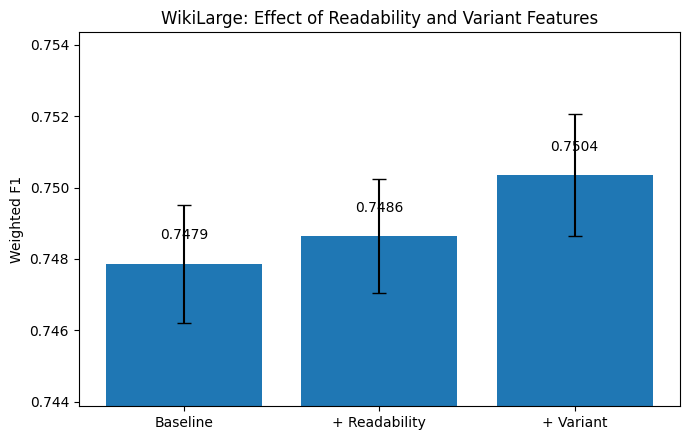

In [ ]:
import matplotlib.pyplot as plt


# Order configs manually
config_order = [
    "Baseline: Char TF-IDF + LinearSVC",
    "Baseline + Readability",
    "Baseline + Readability + Variant"
]

short_labels = [
    "Baseline",
    "+ Readability",
    "+ Variant"
]

plot_df = (
    results_wikilarge
    .groupby("config")["weighted_f1"]
    .agg(["mean", "std"])
    .loc[config_order]
    .reset_index()
)

x = np.arange(len(plot_df))

plt.figure(figsize=(7, 4.5))

bars = plt.bar(
    x,
    plot_df["mean"],
    yerr=plot_df["std"],
    capsize=5
)

plt.xticks(x, short_labels)
plt.ylabel("Weighted F1")
plt.title("WikiLarge: Effect of Readability and Variant Features")

# Zoom in to show small differences clearly
y_min = plot_df["mean"].min() - 0.004
y_max = plot_df["mean"].max() + 0.004
plt.ylim(y_min, y_max)

for i, value in enumerate(plot_df["mean"]):
    plt.text(
        i,
        value + 0.0006,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("wikilarge_weighted_f1_barplot_clean.png", dpi=300, bbox_inches="tight")
plt.show()

# Adding Enhanced Features (POS ratio & Lemma ratio)

In [ ]:
!pip -q install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 63.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

# Enhanced Feature Extractor

In [ ]:

from tqdm.auto import tqdm


def spacy_docs_to_features(texts, batch_size=1000):
    docs = []
    for doc in tqdm(nlp.pipe(texts, batch_size=batch_size), total=len(texts)):
        docs.append([
            {
                "text": token.text.lower(),
                "lemma": token.lemma_.lower(),
                "pos": token.pos_
            }
            for token in doc
            if not token.is_space and not token.is_punct
        ])
    return docs

normal_texts = pairs_wikilarge["Normal"].astype(str).tolist()
simple_texts = pairs_wikilarge["Simple"].astype(str).tolist()

normal_docs = spacy_docs_to_features(normal_texts)
simple_docs = spacy_docs_to_features(simple_texts)

print(len(normal_docs), len(simple_docs))

  0%|          | 0/148843 [00:00<?, ?it/s]

  0%|          | 0/148843 [00:00<?, ?it/s]

148843 148843


In [ ]:
def enhanced_features_from_docs(normal_tokens, simple_tokens):
    normal_words = [t["text"] for t in normal_tokens]
    simple_words = [t["text"] for t in simple_tokens]

    matcher = SequenceMatcher(None, normal_words, simple_words)
    opcodes = matcher.get_opcodes()

    lemma_same = 0
    lemma_total = 0

    pos_same = 0
    pos_total = 0

    for tag, i1, i2, j1, j2 in opcodes:
        if tag == "replace":
            normal_span = normal_tokens[i1:i2]
            simple_span = simple_tokens[j1:j2]
            min_len = min(len(normal_span), len(simple_span))

            for k in range(min_len):
                lemma_total += 1
                pos_total += 1

                if normal_span[k]["lemma"] == simple_span[k]["lemma"]:
                    lemma_same += 1

                if normal_span[k]["pos"] == simple_span[k]["pos"]:
                    pos_same += 1

    return {
        "lemma_ratio": lemma_same / lemma_total if lemma_total else 0,
        "pos_ratio": pos_same / pos_total if pos_total else 0,
    }

rows = []

for i in tqdm(range(len(pairs_wikilarge))):
    feats = enhanced_features_from_docs(normal_docs[i], simple_docs[i])
    feats["dataset"] = "WikiLarge"
    feats["pair_id"] = pairs_wikilarge.loc[i, "pair_id"]
    rows.append(feats)

enhanced_wikilarge = pd.DataFrame(rows)

print(enhanced_wikilarge.shape)
display(enhanced_wikilarge.head())
display(enhanced_wikilarge.describe())

enhanced_wikilarge.to_parquet("wikilarge_enhanced.parquet", index=False)
print("Saved wikilarge_enhanced.parquet")

  0%|          | 0/148843 [00:00<?, ?it/s]

(148843, 4)


,lemma_ratio,pos_ratio,dataset,pair_id
0,0.0,0.300000,WikiLarge,0
1,0.0,1.000000,WikiLarge,1
2,0.0,0.125000,WikiLarge,2
3,0.0,0.047619,WikiLarge,3
4,0.0,0.250000,WikiLarge,4


,lemma_ratio,pos_ratio,pair_id
count,148843.000000,148843.000000,148843.000000
mean,0.023749,0.275640,74421.000000
std,0.117627,0.339004,42967.417396
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,37210.500000
50%,0.000000,0.142857,74421.000000
75%,0.000000,0.500000,111631.500000
max,1.000000,1.000000,148842.000000


Saved wikilarge_enhanced.parquet


In [ ]:
print("Pairs with lemma matches:",
      (enhanced_wikilarge["lemma_ratio"] > 0).mean())

print("Pairs with POS matches:",
      (enhanced_wikilarge["pos_ratio"] > 0).mean())

Pairs with lemma matches: 0.05901520393972172
Pairs with POS matches: 0.5283486626848424


In [ ]:
display(
    enhanced_wikilarge[
        ["lemma_ratio","pos_ratio"]
    ].describe(percentiles=[0.5,0.75,0.9,0.95,0.99])
)

,lemma_ratio,pos_ratio
count,148843.000000,148843.000000
mean,0.023749,0.275640
std,0.117627,0.339004
min,0.000000,0.000000
50%,0.000000,0.142857
75%,0.000000,0.500000
90%,0.000000,1.000000
95%,0.142857,1.000000
99%,0.500000,1.000000
max,1.000000,1.000000


# Adding the enhanced to the model

In [ ]:
ENHANCED_COLS = [
    "lemma_ratio",
    "pos_ratio"
]

model_df_wikilarge_enhanced = model_df_wikilarge.merge(
    enhanced_wikilarge[["dataset", "pair_id"] + ENHANCED_COLS],
    on=["dataset", "pair_id"],
    how="left"
)

print(model_df_wikilarge_enhanced.shape)
display(model_df_wikilarge_enhanced.head())
print(model_df_wikilarge_enhanced.isna().sum())

(297686, 18)


,dataset,pair_id,text,label,label_name,sentence_len,avg_word_len,type_token_ratio,char_len,punctuation_ratio,same_ratio,replace_ratio,insert_ratio,delete_ratio,compression_ratio,length_diff_ratio,lemma_ratio,pos_ratio
0,WikiLarge,0,there is manuscript evidence that austen conti...,0,normal,34,4.588235,0.764706,190,0.005263,0.450000,0.300000,0.1,0.150000,1.000000,0.000000,0.0,0.300000
1,WikiLarge,1,in a remarkable comparative analysis mandaean ...,0,normal,24,5.250000,0.875000,150,0.006667,0.750000,0.041667,0.0,0.208333,0.791667,0.208333,0.0,1.000000
2,WikiLarge,2,before persephone was released to hermes who h...,0,normal,42,4.642857,0.833333,237,0.004219,0.041667,0.958333,0.0,0.000000,0.976190,0.023810,0.0,0.125000
3,WikiLarge,3,geneva lrb rrb is the second most populous cit...,0,normal,32,4.437500,0.625000,174,0.005747,0.088235,0.911765,0.0,0.000000,0.812500,0.187500,0.0,0.047619
4,WikiLarge,4,when japan earned another race on the f schedu...,0,normal,17,4.352941,1.000000,91,0.010989,0.764706,0.235294,0.0,0.000000,1.000000,0.000000,0.0,0.250000


dataset              0
pair_id              0
text                 0
label                0
label_name           0
sentence_len         0
avg_word_len         0
type_token_ratio     0
char_len             0
punctuation_ratio    0
same_ratio           0
replace_ratio        0
insert_ratio         0
delete_ratio         0
compression_ratio    0
length_diff_ratio    0
lemma_ratio          0
pos_ratio            0
dtype: int64


In [ ]:
def evaluate_config(
    df,
    config_name,
    use_readability=False,
    use_variant=False,
    use_enhanced=False,
    n_splits=5,
    random_state=42
):
    X_text = df["text"].values
    y = df["label"].values
    groups = df["pair_id"].values

    sgkf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(sgkf.split(X_text, y, groups), 1):
        X_train_text = X_text[train_idx]
        X_test_text = X_text[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        vectorizer = TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=2,
            max_features=100000
        )

        X_train = vectorizer.fit_transform(X_train_text)
        X_test = vectorizer.transform(X_test_text)

        extra_cols = []

        if use_readability:
            extra_cols += READABILITY_COLS

        if use_variant:
            extra_cols += VARIANT_COLS

        if use_enhanced:
            extra_cols += ENHANCED_COLS

        if extra_cols:
            scaler = RobustScaler()

            X_train_extra = scaler.fit_transform(df.iloc[train_idx][extra_cols].values)
            X_test_extra = scaler.transform(df.iloc[test_idx][extra_cols].values)

            X_train = hstack([X_train, csr_matrix(X_train_extra)])
            X_test = hstack([X_test, csr_matrix(X_test_extra)])

        clf = LinearSVC(
            class_weight="balanced",
            random_state=random_state,
            max_iter=5000
        )

        clf.fit(X_train, y_train)
        pred = clf.predict(X_test)

        fold_results.append({
            "dataset": df["dataset"].iloc[0],
            "config": config_name,
            "fold": fold,
            "accuracy": accuracy_score(y_test, pred),
            "macro_f1": f1_score(y_test, pred, average="macro"),
            "weighted_f1": f1_score(y_test, pred, average="weighted"),
            "precision_macro": precision_score(y_test, pred, average="macro"),
            "recall_macro": recall_score(y_test, pred, average="macro")
        })

        print(config_name, "fold", fold, "weighted_f1:", fold_results[-1]["weighted_f1"])

    return pd.DataFrame(fold_results)

In [ ]:
results_enhanced_wikilarge = evaluate_config(
    model_df_wikilarge_enhanced,
    config_name="Baseline + Readability + Variant + Enhanced",
    use_readability=True,
    use_variant=True,
    use_enhanced=True
)

results_wikilarge_full = pd.concat(
    [results_wikilarge, results_enhanced_wikilarge],
    ignore_index=True
)

summary_wikilarge_full = results_wikilarge_full.groupby(["dataset", "config"])[
    ["accuracy", "macro_f1", "weighted_f1", "precision_macro", "recall_macro"]
].agg(["mean", "std"])

display(summary_wikilarge_full)

results_wikilarge_full.to_csv("wikilarge_results_folds_full.csv", index=False)
summary_wikilarge_full.to_csv("wikilarge_results_summary_full.csv")
model_df_wikilarge_enhanced.to_parquet("wikilarge_model_df_enhanced.parquet", index=False)

Baseline + Readability + Variant + Enhanced fold 1 weighted_f1: 0.7519395645997001
Baseline + Readability + Variant + Enhanced fold 2 weighted_f1: 0.7514693887493464
Baseline + Readability + Variant + Enhanced fold 3 weighted_f1: 0.7482941839135061
Baseline + Readability + Variant + Enhanced fold 4 weighted_f1: 0.7513401416694697
Baseline + Readability + Variant + Enhanced fold 5 weighted_f1: 0.7487061764716166


accuracy            \
                                                           mean       std   
dataset   config                                                            
WikiLarge Baseline + Readability                       0.748645  0.001609   
          Baseline + Readability + Variant             0.750354  0.001714   
          Baseline + Readability + Variant + Enhanced  0.750351  0.001710   
          Baseline: Char TF-IDF + LinearSVC            0.747869  0.001654   

                                                       macro_f1            \
                                                           mean       std   
dataset   config                                                            
WikiLarge Baseline + Readability                       0.748644  0.001610   
          Baseline + Readability + Variant             0.750353  0.001714   
          Baseline + Readability + Variant + Enhanced  0.750350  0.001709   
          Baseline: Char TF-IDF + LinearSVC            0.747868  0.001655   

                                                      weighted_f1            \
                                                             mean       std   
dataset   config                                                              
WikiLarge Baseline + Readability                         0.748644  0.001610   
          Baseline + Readability + Variant               0.750353  0.001714   
          Baseline + Readability + Variant + Enhanced    0.750350  0.001709   
          Baseline: Char TF-IDF + LinearSVC              0.747868  0.001655   

                                                      precision_macro  \
                                                                 mean   
dataset   config                                                        
WikiLarge Baseline + Readability                             0.748648   
          Baseline + Readability + Variant                   0.750359   
          Baseline + Readability + Variant + Enhanced        0.750356   
          Baseline: Char TF-IDF + LinearSVC                  0.747871   

                                                                recall_macro  \
                                                            std         mean   
dataset   config                                                               
WikiLarge Baseline + Readability                       0.001605     0.748645   
          Baseline + Readability + Variant             0.001716     0.750354   
          Baseline + Readability + Variant + Enhanced  0.001711     0.750351   
          Baseline: Char TF-IDF + LinearSVC            0.001651     0.747869   

                                                                 
                                                            std  
dataset   config                                                 
WikiLarge Baseline + Readability                       0.001609  
          Baseline + Readability + Variant             0.001714  
          Baseline + Readability + Variant + Enhanced  0.001710  
          Baseline: Char TF-IDF + LinearSVC            0.001654